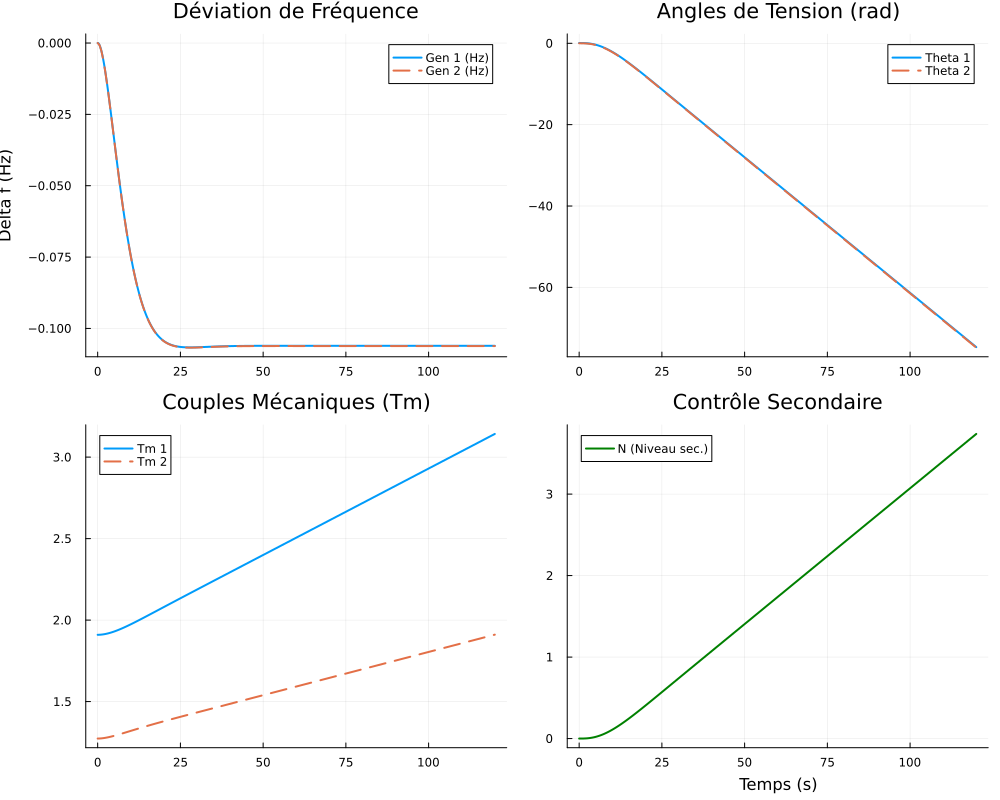

In [6]:
using DifferentialEquations
using Plots
using LinearAlgebra

# ==============================================================================
# 1. DÉFINITION DES PARAMÈTRES (Basé sur Section 4 du document)
# ==============================================================================
# Paramètres généraux
const f0 = 50.0
const w0 = 100 * pi          # [cite: 97]
const Ks = 0.05              # Gain contrôle secondaire [cite: 99]

# Paramètres des Générateurs (Table 1 [cite: 110])
# Note: C dans la table correspond à alpha dans les équations (Eq 42)
# Gen 1
const P0_1 = 600.0
const Pmax_1 = 1000.0
const Pmin_1 = 0.0
const Pr_1 = 100.0
const J1 = 0.4
const D1 = 0.04
const alpha1 = 100.0 
const beta1 = 2000.0

# Gen 2
const P0_2 = 400.0
const Pmax_2 = 600.0
const Pmin_2 = 0.0
const Pr_2 = 50.0
const J2 = 0.1
const D2 = 0.02
const alpha2 = 100.0
const beta2 = 2000.0

# ==============================================================================
# 2. FONCTION DU SYSTÈME DYNAMIQUE
# ==============================================================================
function power_grid_dynamics!(dX, X, p, t)
    # Décomposition du vecteur d'état X 
    theta1, w1, Tm1, theta2, w2, Tm2, N = X

    # --- Gestion des Événements et Entrées ---
    
    # 1. Disjonction de ligne à t = 15s (Section 4.8 )
    # KL passe de 3064 (2 lignes) à 1532 (1 ligne)
    # KL = (t < 15.0) ? 3064.0 : 1532.0
    KL = 3064.0 

    # 2. Évolution des Charges (Section 4.6 [cite: 127, 128, 129])
    # Load 1: +100 MW sur 60s, Load 2: +200 MW sur 60s
    PL1 = 400.0 + (100.0 / 60.0) * t
    PL2 = 600.0 + (200.0 / 60.0) * t

    # --- Équations du Réseau (Grid) (Eq 1 [cite: 28]) ---
    F12 = KL * (theta1 - theta2)
    PG1 = PL1 + F12
    PG2 = PL2 - F12

    # --- Contrôle Primaire (Consignes Pc) (Eq 38, 48 [cite: 38, 48]) ---
    # Saturation bornée par Pmin et Pmax
    Pc1_raw = P0_1 + N * Pr_1
    # Pc1 = clamp(Pc1_raw, Pmin_1, Pmax_1)
    Pc1 = Pc1_raw

    Pc2_raw = P0_2 + N * Pr_2
    # Pc2 = clamp(Pc2_raw, Pmin_2, Pmax_2)
    Pc2 = Pc2_raw

    # --- Dynamique Générateur 1 ---
    # Angle de tension (Eq 36 [cite: 36])
    dX[1] = w1 - w0 
    
    # Équation mécanique (Eq 37 [cite: 37])
    # Note: Utilisation du modèle non-linéaire (PG1 / w1) au lieu de l'approx linéarisée
    dX[2] = (1/J1) * (Tm1 - (PG1/w0) - D1*(w1 - w0))
    
    # Dynamique de la turbine/gouverneur (Eq 42 [cite: 42])
    # Pm = Tm * w. L'équation est dTm/dt = -alpha*(Pm - Pc) - beta*(w - w0)
    Pm1 = Tm1 * w0
    dX[3] = -alpha1 * (Pm1 - Pc1) - beta1 * (w1 - w0)

    # --- Dynamique Générateur 2 ---
    # Angle de tension (Eq 46 [cite: 46])
    dX[4] = w2 - w0
    
    # Équation mécanique (Eq 47 [cite: 47])
    dX[5] = (1/J2) * (Tm2 - (PG2/w0) - D2*(w2 - w0))
    
    # Dynamique de la turbine/gouverneur (Eq 52 [cite: 52])
    Pm2 = Tm2 * w0
    dX[6] = -alpha2 * (Pm2 - Pc2) - beta2 * (w2 - w0)

    # --- Contrôle Secondaire (Fréquence) ---
    # Fréquence moyenne pondérée (Eq 56 [cite: 56])
    wr = (J1 * w1 + J2 * w2) / (J1 + J2)
    
    # Dynamique de l'intégrateur N (dérivée de l'Eq 58 pour un contrôle intégral )
    # Si N est l'état intégral, alors dN/dt = -Ks * (wr - w0)
    dX[7] = -Ks * (wr - w0)
end

# ==============================================================================
# 3. INITIALISATION ET RÉSOLUTION
# ==============================================================================

# Calcul des conditions initiales (Steady State à t=0)
# Charges initiales: PL1=400, PL2=600. GenSet: P0_1=600, P0_2=400.
# Bilan: Gen (1000) = Load (1000). Donc N initial ≈ 0.
# Flux F12 = P0_1 - PL1 = 600 - 400 = 200 MW.
# Theta1 - Theta2 = F12 / KL_init = 200 / 3064.
theta_diff_0 = 200.0 / 3064.0
Tm1_0 = 600.0 / w0 # Couple initial pour fournir 600MW à w0
Tm2_0 = 400.0 / w0 # Couple initial pour fournir 400MW à w0

# Vecteur d'état initial X0 = [theta1, w1, Tm1, theta2, w2, Tm2, N]
x0 = [theta_diff_0, w0, Tm1_0, 0.0, w0, Tm2_0, 0.0]

# Intervalle de temps (0 à 60s)
tspan = (0.0, 120.0)

# Définition du problème ODE
prob = ODEProblem(power_grid_dynamics!, x0, tspan)

# Résolution (avec une précision adaptée aux systèmes raides)
sol = solve(prob, Rodas5(), reltol=1e-8, abstol=1e-8)

# ==============================================================================
# 4. VISUALISATION DES RÉSULTATS
# ==============================================================================

# Plot 1: Fréquences (w1, w2) - Déviation par rapport à w0
p1 = plot(sol.t, (sol[2,:] .- w0) ./ (2*pi), label="Gen 1 (Hz)", title="Déviation de Fréquence", lw=2)
plot!(p1, sol.t, (sol[5,:] .- w0) ./ (2*pi), label="Gen 2 (Hz)", lw=2, linestyle=:dash)
ylabel!(p1, "Delta f (Hz)")

# Plot 2: Angles de tension (theta1, theta2)
p2 = plot(sol.t, sol[1,:], label="Theta 1", title="Angles de Tension (rad)", lw=2)
plot!(p2, sol.t, sol[4,:], label="Theta 2", lw=2, linestyle=:dash)

# Plot 3: Couples Mécaniques (Tm1, Tm2)
p3 = plot(sol.t, sol[3,:], label="Tm 1", title="Couples Mécaniques (Tm)", lw=2)
plot!(p3, sol.t, sol[6,:], label="Tm 2", lw=2, linestyle=:dash)

# Plot 4: Variable de Contrôle Secondaire (N)
p4 = plot(sol.t, sol[7,:], label="N (Niveau sec.)", title="Contrôle Secondaire", lw=2, color=:green)
xlabel!(p4, "Temps (s)")

# Assemblage final
final_plot = plot(p1, p2, p3, p4, layout=(2,2), size=(1000, 800))

# Afficher le plot
display(final_plot)